In [47]:
import numpy as np
import torch
from train_reinforce import BinPacking_Environment, get_action_from_idx
from PackingUtils import *
from ModelEMS import *
import datetime
import random
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import copy
import torch
import numpy as np
from typing import List, Tuple

class TreeNode:
    def __init__(self, state: 'BinPacking_Environment', parent=None, action_idx=None, reward=0):
        self.state = state  # 当前环境状态
        self.parent = parent  # 父节点
        self.action_idx = action_idx  # 从父节点到当前节点的动作索引
        self.reward = reward  # 当前动作的奖励
        self.children = []  # 子节点列表

    def is_leaf(self):
        return len(self.children) == 0

    def add_child(self, child_node):
        self.children.append(child_node)

def dfs_search(node: TreeNode, model, depth: int, max_depth: int, top_k: int = 2) -> Tuple[float, List[int]]:
    if depth == max_depth or node.state.item_ptr >= len(node.state.items_list):
        return node.reward, []
    
    placement, item_state, height_map, mask = node.state.get_state()
    
    with torch.no_grad():
        ems_state, item_state_out, ems_feature, item_feature, logits_raw_, logits = model(
            placement,
            item_state,
            height_map,
            mask
        )
    #最有可能的k个动作
    topk = torch.topk(logits, top_k, dim=-1)
    top_actions = topk.indices.squeeze().tolist()
    
    if isinstance(top_actions, int):
        top_actions = [top_actions]
    
    best_total_reward = -np.inf
    best_action_sequence = []
    
    for action_idx in top_actions:
        # 生成动作，不包含 height
        action = get_action_from_idx(
            placement,
            action_idx,
            node.state.clip_num,
            height_map=node.state.height_map,
            item_size=node.state.items_list[node.state.item_ptr].tolist(),
            return_height=False  # 不返回 height
        )
        print(f"action: {action}")
        
        child_env = copy.deepcopy(node.state)
        
        reward, done = child_env.step(action, False)
        
        child_node = TreeNode(state=child_env, parent=node, action_idx=action_idx, reward=reward)
        node.add_child(child_node)
        
        total_reward, action_sequence = dfs_search(child_node, model, depth + 1, max_depth, top_k)
        
        if total_reward > best_total_reward:
            best_total_reward = total_reward
            best_action_sequence = [action_idx] + action_sequence
    
    return best_total_reward, best_action_sequence


def run_policy_dfs(item_list: List[np.ndarray], model_filename: str, device_name: str, container_dim=(100, 100, 100), clip_num=50, max_depth: int = 20, top_k: int = 2):
    device = torch.device(device_name)
    model = BPP_Model_EMS(
        num_placement=clip_num,
        batch_size=1,
        embed_size=128,
        feature_mlp_layers=[256, 128],
        feature_mlp_output=64
    ).to(device)
    model.load_state_dict(torch.load(model_filename, map_location=device, weights_only=True))
    model.eval()
    
    env = BinPacking_Environment(container_dim, item_list, clip_num=clip_num, device=device_name)
    
    root = TreeNode(state=copy.deepcopy(env))
    total_reward, action_sequence = dfs_search(root, model, depth=0, max_depth=max_depth, top_k=top_k)
    
    # 执行动作序列
    env = BinPacking_Environment(container_dim, item_list, clip_num=clip_num, device=device_name)
    used_bins_idx = []
    actions = []
    
    for action_idx in action_sequence:
        placement, item_state, height_map, mask = env.get_state()
        
        # 获取不包含 height 的动作用于 step
        action = get_action_from_idx(
            placement,
            action_idx,
            env.clip_num,
            height_map=env.height_map,
            item_size=env.items_list[env.item_ptr].tolist(),
            return_height=False  # 不返回 height
        )
        print(f"action: {action}")

        reward, done = env.step(action, False)
        actions.append(action)
        
        if reward == 0:
            print(f"Skip this step: item {env.get_current_item()}")
            env.item_ptr += 1
            if env.item_ptr >= len(item_list):
                break
        else:
            if env.item_ptr not in used_bins_idx:
                used_bins_idx.append(env.item_ptr)
        
        if done:
            break
    
    print(f"Total Reward: {total_reward}")
    print(f"Used items: {env.used} / {len(env.items_list)}")
    return env, used_bins_idx, actions


In [66]:
def run_policy(item_list, model_filename, device_name, container_dim=(100, 100, 100), clip_num=50):
	device = torch.device(device_name)
	model = BPP_Model_EMS(num_placement=clip_num, batch_size=1, embed_size=128, feature_mlp_layers=[256, 128], feature_mlp_output=64).to(device)
	model.load_state_dict(torch.load(model_filename, map_location=device, weights_only=True))
	max_steps = 200
	used_bins_idx = []

	env = BinPacking_Environment(container_dim, item_list, clip_num=clip_num, device=device_name)
	step_cnt = 0
	done = False
	states, action_ids, rewards, actions = [], [], [], []
	model.eval()
	while not done:
		placement, item_info, height_map, feasibility_mask = env.get_state()
		ems_state, item_state, ems_feature, item_feature, logits_raw_, logits = model(
			placement,
			item_info,
			height_map,
			feasibility_mask
		)
		# print(feasibility_mask)
		# print(logits)
		# if torch.any(logits < 0) or torch.any(logits == torch.nan) or torch.any(logits == torch.inf):
		# 	print(f"logits < 0 exists")
		# 	print(logits)
		# print(logits)
		try:
			# action_idx = torch.multinomial(logits, 1).item()
			# action_idx = torch.topk(logits, 1, dim=-1).indices[0].item()
			action_idx = torch.argmax(logits, dim=-1).item()
			# print(logits)
		except Exception as e:
			print(f"Error: {e}")
			print(item_list)
			print(logits)
			print(logits_raw_)
			print("feasibility mask: ", feasibility_mask)
			print("placement: ", placement)
			print("item_info: ", item_info)
			print("EMS state: ", ems_state)
			print("Item state: ", item_state)
			print("height_map: ", height_map)

			print("EMS feature: ", ems_feature)
			print("Item feature: ", item_feature)
			print("step count: ", step_cnt)
			break
		# print(action_idx)
		item_size = item_info.cpu().detach().numpy()[0, 0].astype(int).tolist()
		# print(item_size, item_size[0])
		action = get_action_from_idx(placement, action_idx, clip_num, height_map=env.height_map, item_size=item_size, return_height=False)
		ax, ay, ar = action
		print(f"action: {action}")
		reward, done = env.step((ax, ay, ar), False)
		if reward == 0:
			print(f"skip this step: item {item_info.cpu().detach().numpy().tolist()}")
			env.item_ptr += 1
			if env.item_ptr >= len(item_list):
				done = True
		else:
			states.append((placement, item_state, height_map, feasibility_mask))
			rewards.append(reward)
			action_ids.append(action_idx)
			actions.append(action)
			if env.item_ptr not in used_bins_idx:
				used_bins_idx.append(env.item_ptr)
		if step_cnt >= max_steps and not done:
			done = True
			# rewards[-1] -= env.get_remaining_cnt() * 0.1
			break
		step_cnt += 1
	print(f"Used items: {env.used} / {len(env.items_list)}")
	return env, used_bins_idx, actions

In [77]:

items = np.load("dataset_map/item_list.npy")
# print(items)
item_list_ = items.tolist()
print(item_list_)
item_list = []
for item in item_list_:
	item_list.append(np.array(item))
# train()
item_list.sort(key=lambda x: max(x[0], x[1]), reverse=True)
print(item_list)
# random.shuffle(item_list)


[[19, 13, 5], [19, 49, 20], [19, 10, 37], [19, 19, 3], [19, 68, 3], [19, 21, 39], [19, 12, 38], [19, 24, 8], [19, 41, 29], [19, 41, 10], [19, 24, 2], [19, 24, 29], [19, 3, 10], [19, 3, 27], [81, 100, 7], [19, 1, 38], [19, 1, 16], [19, 1, 23], [19, 6, 19], [19, 6, 19], [12, 100, 56], [12, 100, 37], [2, 51, 19], [17, 51, 19], [14, 51, 1], [5, 51, 1], [69, 100, 22], [19, 40, 38], [19, 41, 38], [69, 74, 71], [69, 26, 71]]
[array([ 81, 100,   7]), array([ 12, 100,  56]), array([ 12, 100,  37]), array([ 69, 100,  22]), array([69, 74, 71]), array([69, 26, 71]), array([19, 68,  3]), array([ 2, 51, 19]), array([17, 51, 19]), array([14, 51,  1]), array([ 5, 51,  1]), array([19, 49, 20]), array([19, 41, 29]), array([19, 41, 10]), array([19, 41, 38]), array([19, 40, 38]), array([19, 24,  8]), array([19, 24,  2]), array([19, 24, 29]), array([19, 21, 39]), array([19, 13,  5]), array([19, 10, 37]), array([19, 19,  3]), array([19, 12, 38]), array([19,  3, 10]), array([19,  3, 27]), array([19,  1, 38])

In [78]:
env, used_bins_idx, actions = run_policy_dfs(item_list, "model_20250112_124243_.pth", "cuda")
print(used_bins_idx)
print(actions)

action: (99, 0, 0)
action: (99, 0, 0)
action: (99, 0, 0)
action: (68, 0, 0)
action: (68, 26, 0)
action: (68, 0, 0)
action: (87, 0, 0)
action: (87, 0, 0)
action: (85, 0, 0)
action: (87, 0, 0)
action: (73, 0, 0)
action: (87, 0, 0)
action: (87, 0, 0)
action: (87, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0, 0)
action: (0, 0

KeyboardInterrupt: 

In [69]:
height_map = env.height_map
state = None
if env.item_ptr == len(item_list):
	print("success")
else:
	coming_item = env.items_list[env.item_ptr]
	print(f"coming item: {coming_item}")
	states = env.get_state()
utilization = env.get_utilization()
print(f"utilization: {utilization}")

success
utilization: 0.872016


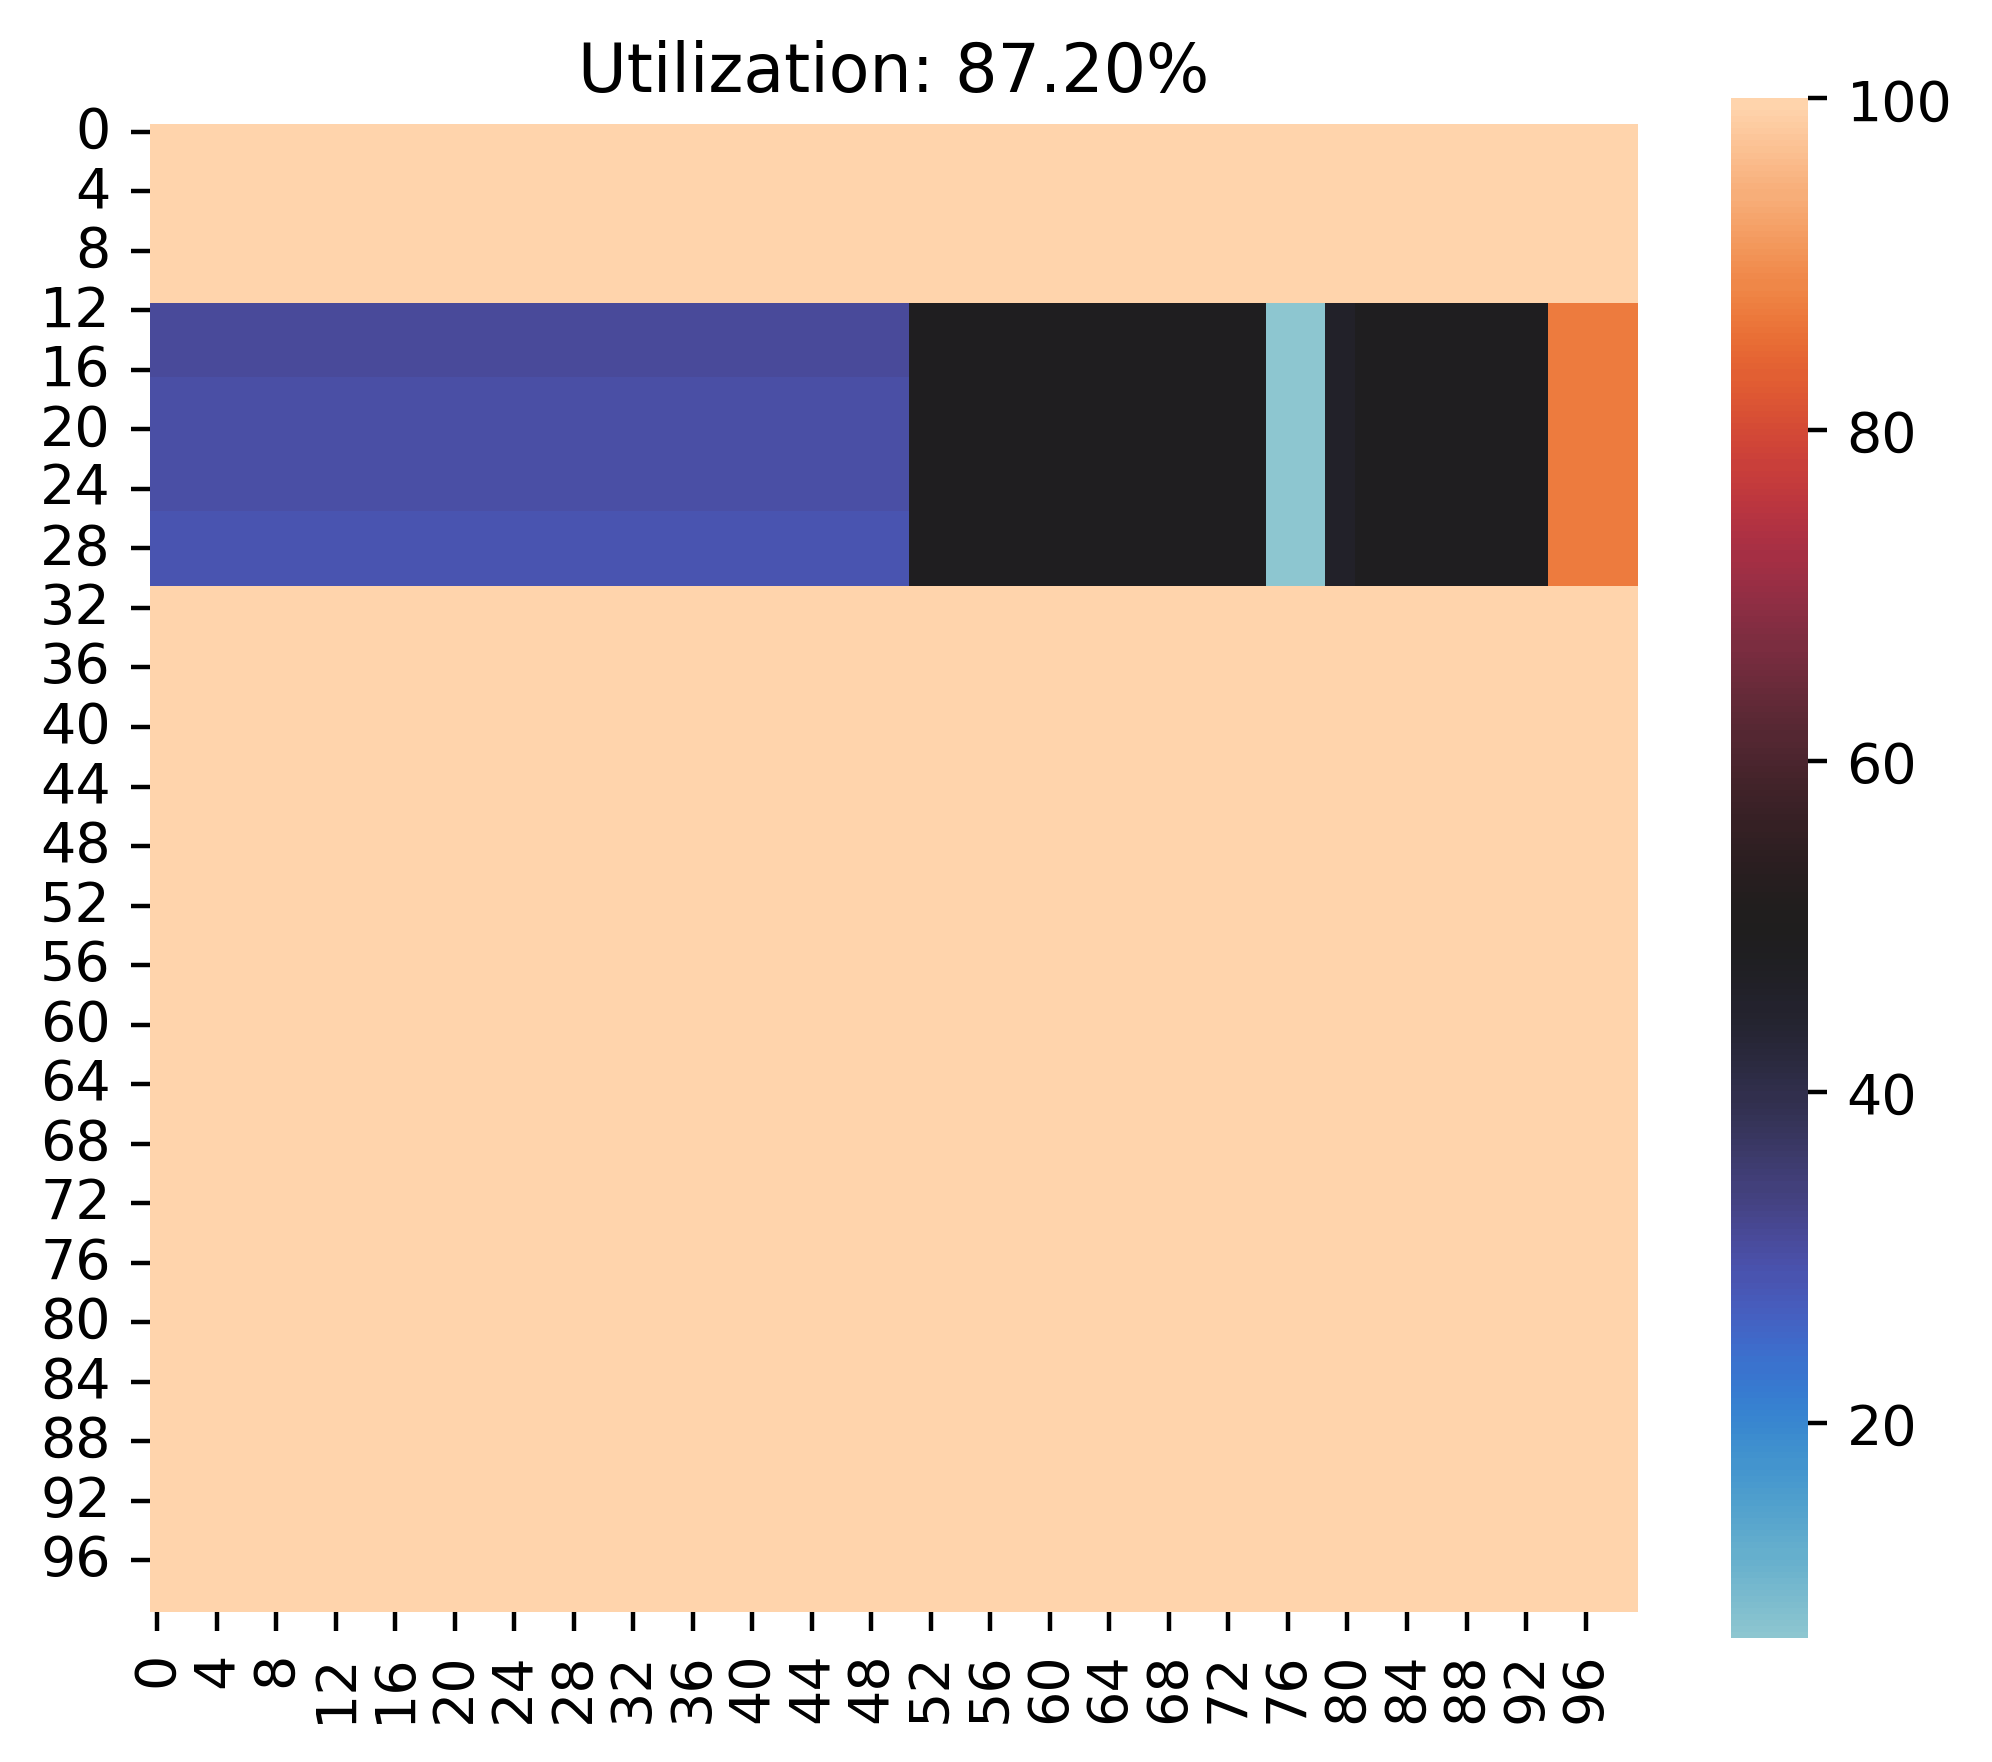

In [13]:
fig = plt.figure(figsize=(6, 5), dpi=400)
sns.heatmap(height_map, square=True, center=50)
plt.title("Utilization: {:.2f}%".format(utilization*100))
plt.savefig("test_bin_packing.png")

In [14]:
if state:
	print(f"placement: {states[0]}")

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
import random
from matplotlib.animation import FuncAnimation

def draw_bins_3d(positions, sizes, filename):
    """
    Draws a 3D animation of bins being added sequentially.
    Each frame adds a new bin.

    Parameters:
    - positions: List of tuples (x, y, z) representing the bottom-left-front corner of each bin.
    - sizes: List of tuples (dx, dy, dz) representing the dimensions of each bin.
    - filename: Output file name for saving the animation.
    """
    # Create figure and 3D axes
    fig = plt.figure(figsize=(6, 5), dpi=100)
    ax = fig.add_subplot(111, projection='3d')
    
    nums = len(positions)
    ranges = [random.random() for _ in range(nums)]
    color_list = plt.cm.tab20b(ranges)

    # Initialize empty collection list
    cuboids = []

    # Define update function for animation
    def update(frame):
        ax.clear()  # Clear the plot
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.set_zlim(0, 100)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

        for i in range(frame + 1):
            x, y, z = positions[i]
            dx, dy, dz = sizes[i]
            facecolor = color_list[i]

            # Define the vertices of the cuboid
            vertices = [
                [x, y, z],
                [x - dx, y, z],
                [x - dx, y + dy, z],
                [x, y + dy, z],
                [x, y, z + dz],
                [x - dx, y, z + dz],
                [x - dx, y + dy, z + dz],
                [x, y + dy, z + dz],
            ]

            # Define the 12 edges of the cuboid
            edges = [
                [vertices[0], vertices[1], vertices[2], vertices[3]],  # Bottom face
                [vertices[4], vertices[5], vertices[6], vertices[7]],  # Top face
                [vertices[0], vertices[1], vertices[5], vertices[4]],  # Front face
                [vertices[2], vertices[3], vertices[7], vertices[6]],  # Back face
                [vertices[1], vertices[2], vertices[6], vertices[5]],  # Right face
                [vertices[0], vertices[3], vertices[7], vertices[4]],  # Left face
            ]

            # Add the cuboid to the plot
            cuboid = Poly3DCollection(edges, alpha=0.8, edgecolor='k', facecolor=facecolor, linewidth=0.5)
            cuboids.append(cuboid)
            ax.add_collection3d(cuboid)

    # Create animation
    anim = FuncAnimation(fig, update, frames=len(positions), interval=500, repeat=False)

    # Save animation
    anim.save(filename, writer='imagemagick' if filename.endswith('.gif') else 'ffmpeg')


[[81, 100, 7], [12, 100, 56], [12, 100, 37], [69, 100, 22], [69, 74, 71], [69, 26, 71], [19, 68, 3], [2, 51, 19], [17, 51, 19], [14, 51, 1], [5, 51, 1], [19, 24, 8], [19, 24, 2], [19, 24, 29], [19, 21, 39], [19, 19, 3], [19, 6, 19], [19, 6, 19]]
[[80, 0, 0.0], [11, 0, 7.0], [11, 0, 63.0], [99, 0, 7.0], [99, 0, 29.0], [99, 74, 29.0], [30, 0, 7.0], [13, 0, 10.0], [30, 0, 10.0], [25, 0, 29.0], [16, 0, 30.0], [30, 51, 10.0], [30, 51, 18.0], [30, 51, 20.0], [30, 79, 7.0], [30, 81, 46.0], [30, 94, 49.0], [30, 94, 68.0]]


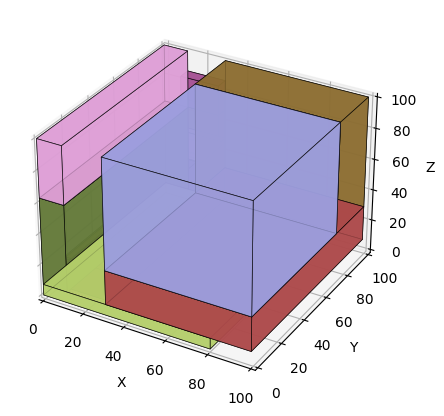

In [16]:

# ax = fig.add_subplot(111, projection='3d')

bins = [item_list[idx-1].tolist() for idx in used_bins_idx]
positions = []
print(bins)
n_used_bins = len(used_bins_idx)
for i in range(n_used_bins):
	xpos, ypos, rotate, zpos = actions[i]
	if rotate == 1:
		bins[i] = [bins[i][1], bins[i][0], bins[i][2]]
	positions.append([xpos, ypos, zpos])
print(positions)
# ax.voxels(bins, edgecolor='k')
draw_bins_3d(positions, bins, "models/bin_packing_3d.mp4")

In [10]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
fig = plt.figure(figsize=(6, 5), dpi=100)

def draw_bins_3d(positions, sizes, filename):
    """
    Draws a 3D figure of bins given their positions and sizes.

    Parameters:
    - positions: List of tuples (x, y, z) representing the bottom-left-front corner of each bin.
    - sizes: List of tuples (dx, dy, dz) representing the dimensions of each bin.
    """
    fig = plt.figure(figsize=(6, 5), dpi=400)
    ax = fig.add_subplot(111, projection='3d')
    nums = len(positions)
    ranges = [random.random() for _ in range(nums)]
    print(ranges)
    color_list = plt.cm.tab20b(ranges)

    for i, (pos, size) in enumerate(zip(positions, sizes)):
        x, y, z = pos
        dx, dy, dz = size
        facecolor = color_list[i]

        # Define the vertices of the cuboid
        vertices = [
            [x, y, z],
            [x-dx, y, z],
            [x-dx, y+dy, z],
            [x, y+dy, z],
            [x, y, z+dz],
            [x-dx, y, z+dz],
            [x-dx, y+dy, z+dz],
            [x, y+dy, z+dz],
        ]

        # Define the 12 edges of the cuboid
        edges = [
            [vertices[0], vertices[1], vertices[2], vertices[3]],  # Bottom face
            [vertices[4], vertices[5], vertices[6], vertices[7]],  # Top face
            [vertices[0], vertices[1], vertices[5], vertices[4]],  # Front face
            [vertices[2], vertices[3], vertices[7], vertices[6]],  # Back face
            [vertices[1], vertices[2], vertices[6], vertices[5]],  # Right face
            [vertices[0], vertices[3], vertices[7], vertices[4]],  # Left face
        ]

        # Add the cuboid to the plot
        ax.add_collection3d(Poly3DCollection(edges, alpha=1.0, edgecolor='k', facecolor=facecolor, linewidth=0.1))

    # Set axes limits and labels
    max_dim = max(max(pos[i] + size[i] for pos, size in zip(positions, sizes)) for i in range(3))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_zlim(0, 100)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # plt.show()
    plt.savefig(filename)

# Example usage
# positions = [(0, 0, 0), (1, 1, 1), (2, 2, 2)]  # Bottom-left-front positions of bins
# sizes = [(1, 1, 1), (1, 2, 1), (2, 1, 2)]  # Dimensions (dx, dy, dz) of each bin

# draw_bins_3d(positions, sizes)

<Figure size 600x500 with 0 Axes>

[[81, 100, 7], [12, 100, 56], [12, 100, 37], [69, 100, 22], [69, 74, 71], [69, 26, 71], [19, 68, 3], [2, 51, 19], [17, 51, 19], [14, 51, 1], [5, 51, 1], [19, 41, 10], [19, 24, 8], [19, 24, 2], [19, 24, 29], [19, 13, 5], [19, 19, 3], [19, 3, 10], [19, 3, 27], [19, 1, 38], [19, 1, 16], [19, 1, 23], [19, 6, 19], [19, 6, 19]]
[[80, 0, 0.0], [99, 0, 7.0], [99, 12, 7.0], [99, 24, 7.0], [99, 26, 29.0], [25, 31, 29.0], [67, 0, 63.0], [76, 95, 7.0], [50, 0, 66.0], [50, 0, 85.0], [99, 21, 44.0], [40, 0, 86.0], [99, 0, 63.0], [99, 0, 71.0], [74, 0, 66.0], [93, 0, 73.0], [99, 0, 78.0], [44, 97, 7.0], [25, 26, 29.0], [25, 26, 56.0], [18, 19, 44.0], [75, 0, 63.0], [99, 0, 81.0], [99, 6, 81.0]]
[0.42159621918378754, 0.5036200662636475, 0.22114001426044783, 0.8253778263669995, 0.3283577199695795, 0.07110596124054147, 0.29594179526078346, 0.23159380485272296, 0.7920761214607063, 0.1038172987656415, 0.9255231974007206, 0.34491096493107787, 0.5091480723464963, 0.222503227191992, 0.2029603834618905, 0.831

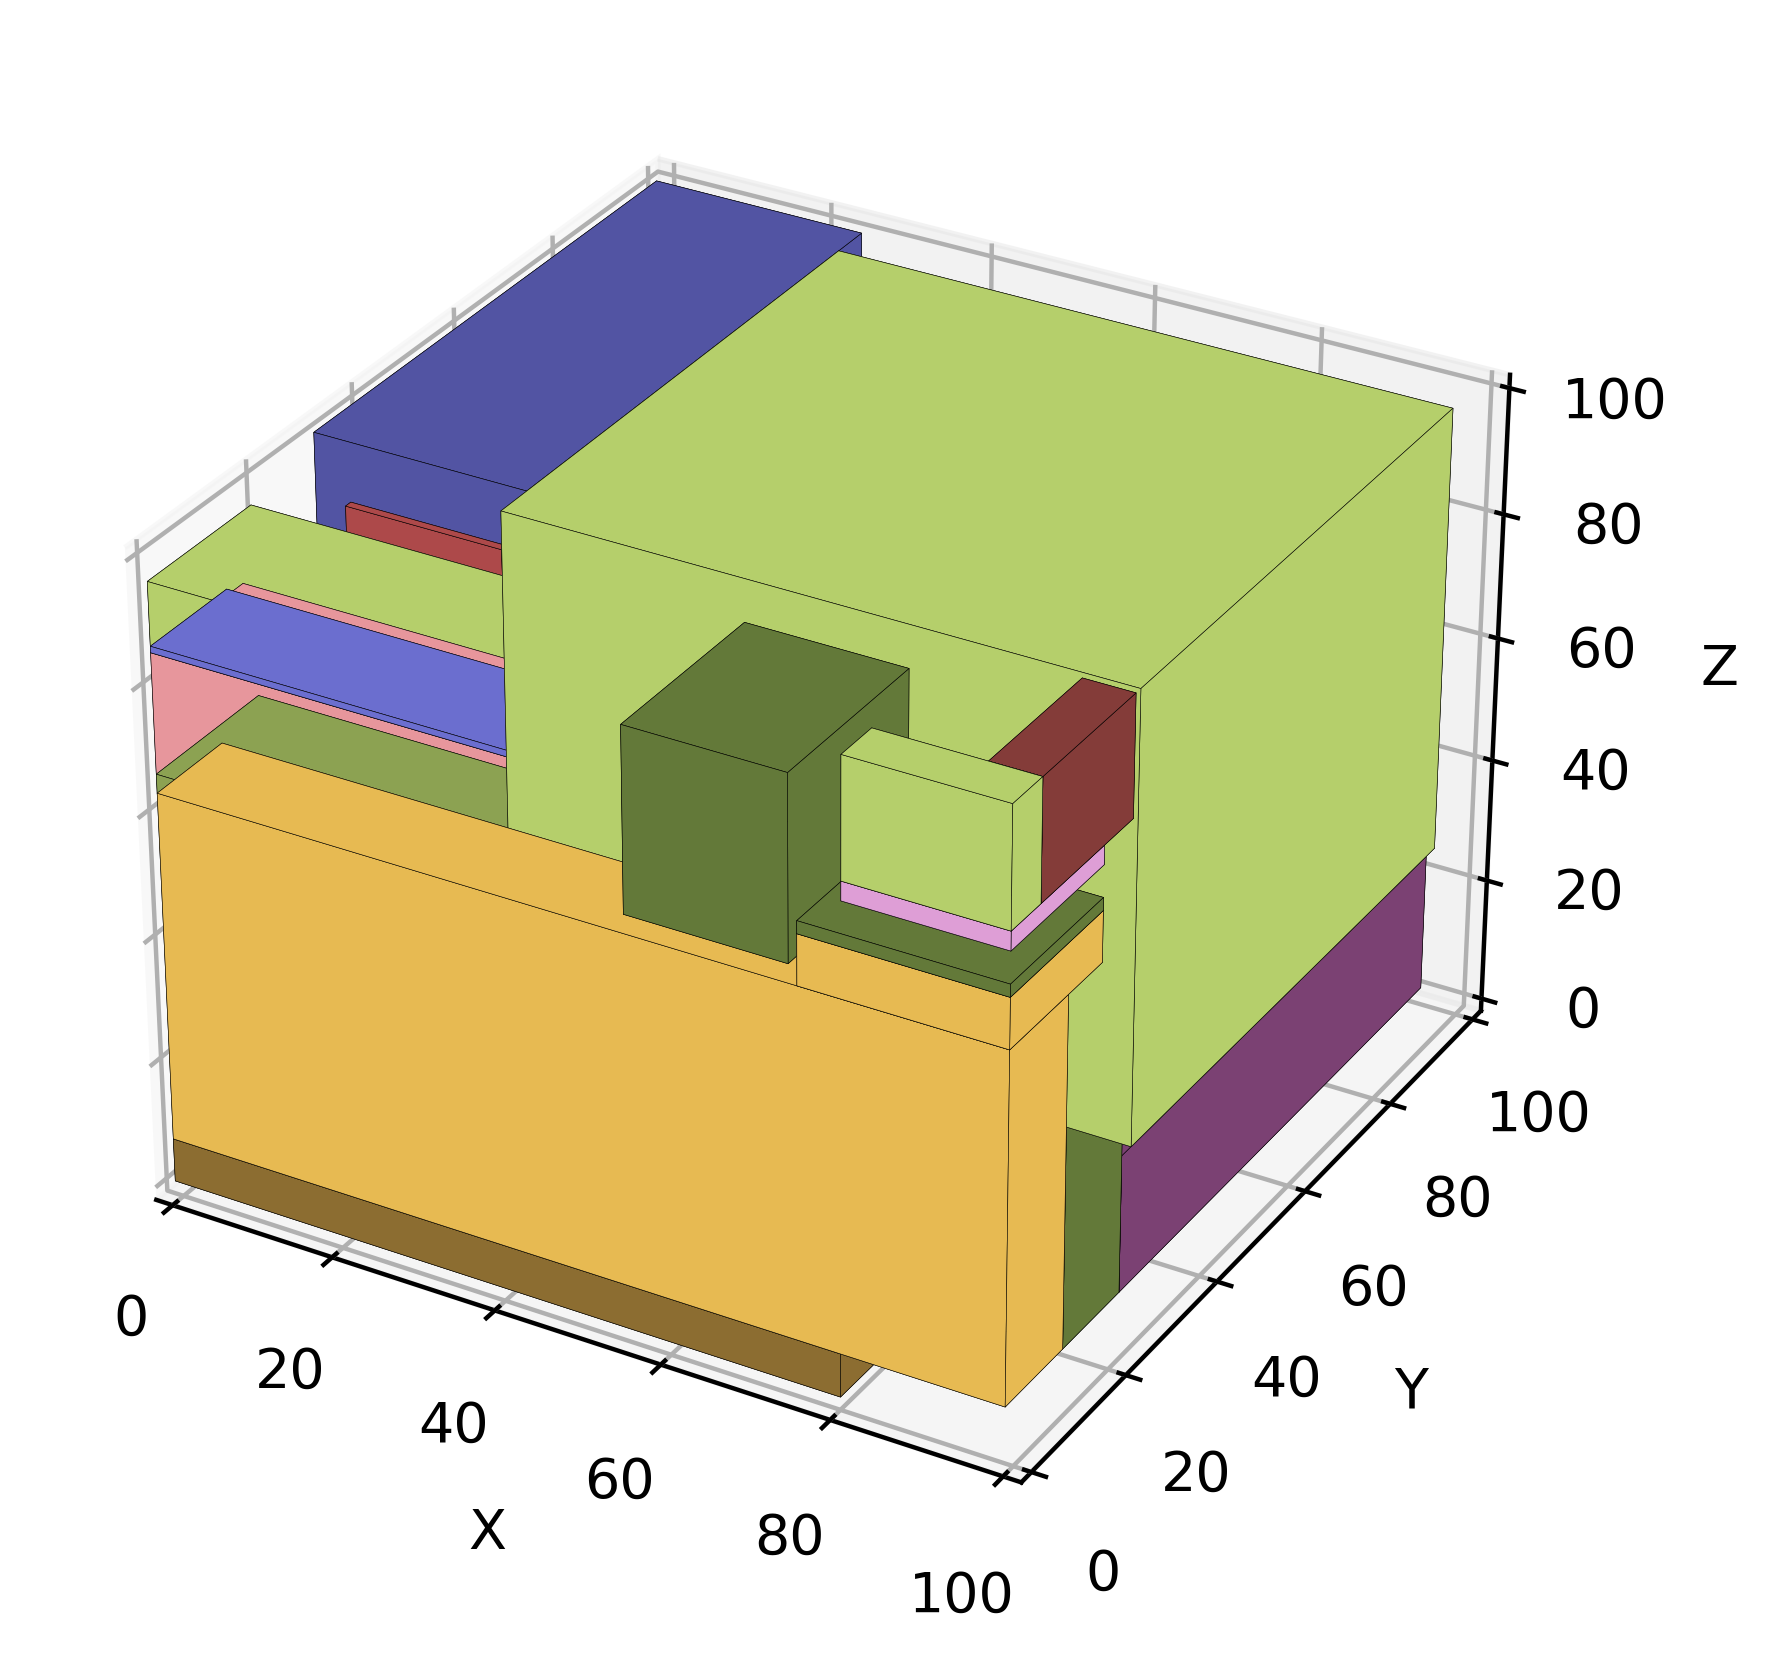

In [12]:

# ax = fig.add_subplot(111, projection='3d')

bins = [item_list[idx-1].tolist() for idx in used_bins_idx]
positions = []
print(bins)
n_used_bins = len(used_bins_idx)
for i in range(n_used_bins):
	xpos, ypos, rotate, zpos = actions[i]
	if rotate == 1:
		bins[i] = [bins[i][1], bins[i][0], bins[i][2]]
	positions.append([xpos, ypos, zpos])
print(positions)
# ax.voxels(bins, edgecolor='k')
draw_bins_3d(positions, bins, "models/bin_packing_3d.png")